# Chapter 31 — Parameters: Numbers the Model Learns

Count-based models stored observations directly in tables.

Neural models instead contain numerical **parameters** that training adjusts to improve predictions.

This chapter isolates that idea with the smallest useful model: one input, one weight, and one numerical prediction.

## Learning goals

By the end of this chapter, you should be able to:

1. Explain what a trainable parameter is.
2. Distinguish inputs, targets, predictions, parameters, and hyperparameters.
3. Compute a prediction from one input and one weight.
4. Compute squared error loss.
5. Search several parameter values manually.
6. Identify the parameter value with the lowest loss.
7. Plot loss across many candidate weights.
8. Evaluate one parameter over a dataset rather than one example.
9. Explain how model architecture limits what parameters can represent.
10. Count parameters in embedding and linear-layer arrays.
11. Connect manual search to later gradient-based training.

## The tiny model

Our architecture is the formula:

```python
prediction = weight * input_number
```

The input is supplied by the data, while `weight` is the model's one trainable parameter.

The target is used after prediction to measure error.

This model has no bias term, so every prediction is forced to pass through zero when the input is zero.

## Terms used in this chapter

An **input** is data supplied to the model.

A **target** is the desired answer used to evaluate the prediction.

A **prediction** is the value computed from inputs and model parameters.

A **trainable parameter** is an internal numerical value eligible to be adjusted by training.

A **weight** is a common kind of parameter.

A **loss** measures prediction error, and training seeks parameter values that reduce average loss.

A **model architecture** specifies how inputs and parameters produce predictions.

## One input and one target

Use input 5 and target 10.

The question is which weight makes `weight × 5` closest to 10.

In [1]:
input_number = 5.0
target_number = 10.0

print("Input:", input_number)
print("Target:", target_number)

Input: 5.0
Target: 10.0


### Make one prediction

Start with weight 1.

In [2]:
weight = 1.0
prediction = weight * input_number

print("Weight:", weight)
print("Prediction:", prediction)
print("Target:", target_number)

Weight: 1.0
Prediction: 5.0
Target: 10.0


The prediction is 5, which is below the target 10.

We need a numerical measure of that mismatch.

## Squared error loss

For this regression-style toy problem, use `(prediction - target)²`.

Earlier language-model chapters used negative log loss for token probabilities.

Squared error is introduced here because its one-parameter curve is easy to inspect; it is not a replacement for next-token negative log loss.

In [3]:
error = prediction - target_number
loss = error**2

print("Prediction:", prediction)
print("Target:", target_number)
print("Error:", error)
print("Squared error loss:", loss)

Prediction: 5.0
Target: 10.0
Error: -5.0
Squared error loss: 25.0


Squaring makes equally sized positive and negative errors receive equal loss and penalizes larger errors more strongly.

In [4]:
for example_error in [-5.0, -2.0, 0.0, 2.0, 5.0]:
    print(f"error={example_error:>4.1f}  squared error={example_error**2:>5.1f}")

error=-5.0  squared error= 25.0
error=-2.0  squared error=  4.0
error= 0.0  squared error=  0.0
error= 2.0  squared error=  4.0
error= 5.0  squared error= 25.0


## Reusable model and loss functions

Separating prediction from evaluation keeps each role explicit.

In [5]:
def predict_with_weight(
    input_number: float,
    weight: float,
) -> float:
    return weight * input_number


def squared_error_loss(
    prediction: float,
    target: float,
) -> float:
    return (prediction - target) ** 2


def evaluate_weight(
    input_number: float,
    target_number: float,
    weight: float,
) -> tuple[float, float]:
    prediction = predict_with_weight(input_number, weight)
    loss = squared_error_loss(prediction, target_number)

    return prediction, loss

In [6]:
prediction, loss = evaluate_weight(
    input_number=5.0,
    target_number=10.0,
    weight=2.0,
)

print("Prediction:", prediction)
print("Loss:", loss)

assert prediction == 10.0
assert loss == 0.0

Prediction: 10.0
Loss: 0.0


Weight 2 produces the target exactly, so this example's loss is zero.

## Try several weights manually

Each candidate parameter produces a prediction and loss.

In [7]:
candidate_weights = [-1.0, 0.0, 1.0, 2.0, 3.0]

print("weight | prediction | loss")
print("-" * 34)

for candidate_weight in candidate_weights:
    prediction, loss = evaluate_weight(
        input_number,
        target_number,
        candidate_weight,
    )
    print(f"{candidate_weight:>6.1f} | {prediction:>10.1f} | {loss:>6.1f}")

weight | prediction | loss
----------------------------------
  -1.0 |       -5.0 |  225.0
   0.0 |        0.0 |  100.0
   1.0 |        5.0 |   25.0
   2.0 |       10.0 |    0.0
   3.0 |       15.0 |   25.0


This table shows the core evaluation cycle: choose a parameter, make a prediction, and measure its loss.

## Find the best candidate

Manual search retains the candidate with the smallest observed loss.

In [8]:
best_weight: float | None = None
best_prediction: float | None = None
best_loss: float | None = None

for candidate_weight in candidate_weights:
    candidate_prediction, candidate_loss = evaluate_weight(
        input_number,
        target_number,
        candidate_weight,
    )

    if best_loss is None or candidate_loss < best_loss:
        best_weight = candidate_weight
        best_prediction = candidate_prediction
        best_loss = candidate_loss

print("Best weight:", best_weight)
print("Best prediction:", best_prediction)
print("Best loss:", best_loss)

assert best_weight == 2.0
assert best_prediction == 10.0
assert best_loss == 0.0

Best weight: 2.0
Best prediction: 10.0
Best loss: 0.0


The result is best only relative to the candidates searched, although this candidate set happens to include the exact solution.

## Evaluate a dense range of weights

Use weights from -1 through 4 in increments of 0.05 to reveal the loss curve.

In [9]:
weights_to_plot = [-1.0 + step * 0.05 for step in range(101)]
single_example_losses = []

for candidate_weight in weights_to_plot:
    _, candidate_loss = evaluate_weight(
        input_number,
        target_number,
        candidate_weight,
    )
    single_example_losses.append(candidate_loss)

best_plot_index = min(
    range(len(weights_to_plot)),
    key=lambda index: single_example_losses[index],
)
best_plot_weight = weights_to_plot[best_plot_index]
best_plot_loss = single_example_losses[best_plot_index]

print("Number of candidates:", len(weights_to_plot))
print("Best plotted weight:", best_plot_weight)
print("Best plotted loss:", best_plot_loss)

Number of candidates: 101
Best plotted weight: 2.0
Best plotted loss: 0.0


## One parameter over a dataset

Training normally minimizes average loss across many examples rather than loss on one example.

The first dataset follows `target = 2 × input` exactly.

In [10]:
perfectly_scaled_examples = [
    (5.0, 10.0),
    (2.0, 4.0),
    (8.0, 16.0),
]


def average_dataset_loss(
    examples: list[tuple[float, float]],
    weight: float,
) -> float:
    if len(examples) == 0:
        raise ValueError("examples must not be empty.")

    losses = []

    for example_input, example_target in examples:
        prediction = predict_with_weight(example_input, weight)
        losses.append(squared_error_loss(prediction, example_target))

    return sum(losses) / len(losses)


print("Average loss at weight 2:", average_dataset_loss(perfectly_scaled_examples, 2.0))

Average loss at weight 2: 0.0


One weight fits all three examples because they share exactly the same scaling rule.

### A dataset with no perfect one-weight fit

These targets do not all equal one common weight times their inputs.

In [11]:
imperfect_examples = [
    (5.0, 10.0),
    (2.0, 5.0),
    (8.0, 15.0),
]

dataset_weights = [step * 0.05 for step in range(81)]
dataset_average_losses = [
    average_dataset_loss(imperfect_examples, candidate_weight)
    for candidate_weight in dataset_weights
]

best_dataset_index = min(
    range(len(dataset_weights)),
    key=lambda index: dataset_average_losses[index],
)
best_dataset_weight = dataset_weights[best_dataset_index]
best_dataset_loss = dataset_average_losses[best_dataset_index]

print("Best searched dataset weight:", best_dataset_weight)
print("Best searched average loss:", best_dataset_loss)

Best searched dataset weight: 1.9500000000000002
Best searched average loss: 0.544166666666667


The lowest-loss weight is a compromise because this architecture can only scale inputs and has no separate bias or example-specific behavior.

## Plot the loss landscapes

The left panel shows a perfect one-example solution, while the right shows the best compromise over inconsistent examples.

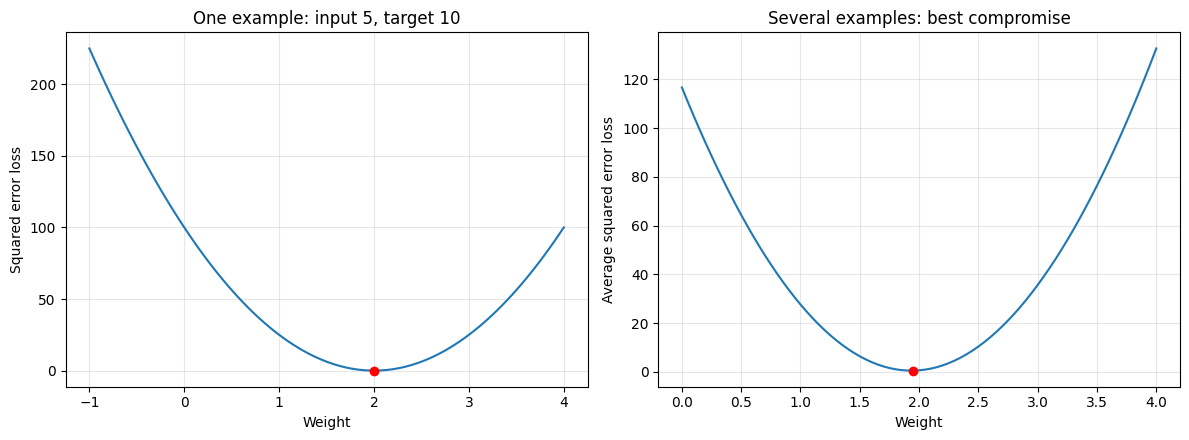

In [12]:
import matplotlib.pyplot as plt

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(weights_to_plot, single_example_losses)
axes[0].scatter([best_plot_weight], [best_plot_loss], color="red", zorder=3)
axes[0].set_xlabel("Weight")
axes[0].set_ylabel("Squared error loss")
axes[0].set_title("One example: input 5, target 10")
axes[0].grid(True, alpha=0.3)

axes[1].plot(dataset_weights, dataset_average_losses)
axes[1].scatter(
    [best_dataset_weight],
    [best_dataset_loss],
    color="red",
    zorder=3,
)
axes[1].set_xlabel("Weight")
axes[1].set_ylabel("Average squared error loss")
axes[1].set_title("Several examples: best compromise")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The bottom of each curve marks the best candidate under its data and loss definition.

Training seeks low points like these without exhaustively plotting every possibility.

## Architecture and parameters have different roles

The architecture `prediction = weight × input` is chosen before training.

Training can change the weight, but it cannot add a bias term or invent a different formula.

If the architecture cannot represent the data pattern, no parameter value will fit perfectly.

## Parameters are not inputs or targets

The model receives the input and uses its stored weight to produce a prediction.

The training procedure then compares that prediction with the target to compute loss.

The target influences later parameter updates, but it is not supplied as an input to this prediction formula.

## Parameters versus hyperparameters

A parameter is learned by the training process.

A hyperparameter is a design or training choice made outside ordinary parameter updates.

Examples of hyperparameters include learning rate, batch size, context length, embedding dimension, and layer count.

In this chapter, `weight` is the parameter, while the candidate grid spacing is an experiment choice.

## Parameters versus computed values

Parameters are stored in the model and eligible for training updates.

Inputs, selected embeddings, hidden states, predictions, and logits are values computed or supplied during a model run.

The same shape can describe either category, so role—not merely shape—determines whether a number is a parameter.

## Parameter arrays in language models

Real models organize parameters into vectors, matrices, and higher-rank arrays.

An embedding table and a linear layer provide two concrete examples.

In [13]:
import numpy as np

parameter_generator = np.random.default_rng(31)

vocabulary_size = 4
embedding_dimension = 3
output_dimension = 5

embedding_table = parameter_generator.normal(
    loc=0.0,
    scale=0.1,
    size=(vocabulary_size, embedding_dimension),
)
linear_weight_matrix = parameter_generator.normal(
    loc=0.0,
    scale=0.1,
    size=(embedding_dimension, output_dimension),
)
linear_bias_vector = np.zeros(output_dimension)

print("Embedding-table shape:", embedding_table.shape)
print("Linear-weight shape:", linear_weight_matrix.shape)
print("Linear-bias shape:", linear_bias_vector.shape)

Embedding-table shape: (4, 3)
Linear-weight shape: (3, 5)
Linear-bias shape: (5,)


The bias begins at zero but remains a parameter because training may change it.

Initialization method and trainability are separate properties.

## Count learned numbers

An array's `.size` reports its number of entries.

The total parameter count is the sum across all trainable parameter arrays.

In [14]:
embedding_parameter_count = embedding_table.size
weight_parameter_count = linear_weight_matrix.size
bias_parameter_count = linear_bias_vector.size
total_parameter_count = (
    embedding_parameter_count + weight_parameter_count + bias_parameter_count
)

print("Embedding parameters:", embedding_parameter_count)
print("Linear-weight parameters:", weight_parameter_count)
print("Linear-bias parameters:", bias_parameter_count)
print("Total parameters:", total_parameter_count)

assert embedding_parameter_count == vocabulary_size * embedding_dimension
assert weight_parameter_count == embedding_dimension * output_dimension
assert bias_parameter_count == output_dimension

Embedding parameters: 12
Linear-weight parameters: 15
Linear-bias parameters: 5
Total parameters: 32


Each count is simply the number of trainable scalar entries, even though the model stores them in structured arrays.

## Training is numerical adjustment, not magical understanding

The tiny model does not reason that 10 divided by 5 is 2.

It computes predictions according to its architecture, receives a numerical loss, and permits its parameter to be adjusted.

Large neural networks have vastly richer architectures and data, but training still consists of numerical updates intended to reduce an objective.

## Manual search does not scale

Searching 501 candidates is manageable for one scalar parameter.

Trying combinations grows exponentially when many parameters vary, making exhaustive search unusable for realistic networks.

Later chapters will use gradients to estimate how each parameter should move without enumerating every combination.

In [15]:
fine_candidate_weights = [-1.0 + step * 0.01 for step in range(501)]
fine_candidate_losses = [
    squared_error_loss(
        predict_with_weight(input_number, candidate_weight),
        target_number,
    )
    for candidate_weight in fine_candidate_weights
]
fine_best_index = min(
    range(len(fine_candidate_weights)),
    key=lambda index: fine_candidate_losses[index],
)

print("Candidates searched:", len(fine_candidate_weights))
print("Best weight:", fine_candidate_weights[fine_best_index])
print("Best loss:", fine_candidate_losses[fine_best_index])

Candidates searched: 501
Best weight: 2.0
Best loss: 0.0


The search succeeds here only because there is one parameter and the exact solution lies on the candidate grid.

## A clean parameter-evaluation pipeline

The final cell evaluates candidates, identifies the lowest loss, and checks the expected solution.

In [16]:
pipeline_input = 5.0
pipeline_target = 10.0
pipeline_weights = [-1.0, 0.0, 1.0, 2.0, 3.0]
pipeline_rows = []

for pipeline_weight in pipeline_weights:
    pipeline_prediction, pipeline_loss = evaluate_weight(
        pipeline_input,
        pipeline_target,
        pipeline_weight,
    )
    pipeline_rows.append((pipeline_weight, pipeline_prediction, pipeline_loss))

pipeline_best_row = min(pipeline_rows, key=lambda row: row[2])

print("Parameter evaluation summary")
print("-" * 38)
print("weight | prediction | loss")

for pipeline_weight, pipeline_prediction, pipeline_loss in pipeline_rows:
    print(
        f"{pipeline_weight:>6.1f} | "
        f"{pipeline_prediction:>10.1f} | "
        f"{pipeline_loss:>6.1f}"
    )

print("Best row:", pipeline_best_row)

assert pipeline_best_row == (2.0, 10.0, 0.0)

Parameter evaluation summary
--------------------------------------
weight | prediction | loss
  -1.0 |       -5.0 |  225.0
   0.0 |        0.0 |  100.0
   1.0 |        5.0 |   25.0
   2.0 |       10.0 |    0.0
   3.0 |       15.0 |   25.0
Best row: (2.0, 10.0, 0.0)


## What not to do

- Do not confuse parameters with inputs, targets, predictions, or hyperparameters.
- Do not treat squared error as the standard language-model token loss.
- Do not assume parameter adjustment can overcome an architecture that cannot represent the data.
- Do not infer understanding merely because training found a low-loss parameter.
- Do not assume zero-initialized values are non-parameters if training can update them.
- Do not expect exhaustive parameter search to scale to neural networks.

## Gotchas

The one-weight model has no bias and can only scale its input.

Lower loss identifies a better parameter only under the chosen architecture, data, and loss function.

Targets participate in training evaluation but are not prediction inputs.

Parameter count means the number of trainable scalar entries, even when stored in arrays.

Large models still consist of numerical parameters adjusted to reduce an objective.

## Takeaways

A trainable parameter is an internal numerical value that training can adjust.

In `prediction = weight × input`, the weight is the parameter, the input is data, the prediction is computed output, and the target is used to calculate loss.

Manual search reveals that weight 2 minimizes squared error for input 5 and target 10.

Datasets, architecture limits, parameter arrays, and parameter counts extend the same idea toward neural language models.

## What comes next

The next chapter introduces gradients informally.

Instead of testing many parameter values, we will use the slope of the loss curve to determine which direction should reduce loss.